# Apartment Price Prediction — End-to-End ML Project

**Goal:** predict apartment sale `price` (EGP) from listing attributes (area, rooms,
bathrooms, floor, year built, seller type, view, payment method, finishing type).

> **Note on the task type:** the raw data has a *continuous* target (`price`), so this
> is a **regression** problem, not classification. The pipeline below mirrors the
> workflow you supplied (clean → EDA → models → grid search → full metrics/plots per
> model) but swaps in regression models and regression metrics (MAE, RMSE, R², MAPE)
> in place of the classification ones (confusion matrix, ROC-AUC, etc.), since those
> don't apply to a continuous target.

**Pipeline**
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Baseline Models (multiple regressors, full metrics + plots each)
5. Hyperparameter Tuning (GridSearchCV) on the top models
6. Final Model Evaluation & Feature Importance


## 1. Imports & Setup

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42


## 2. Load Data

The raw CSV stores several numeric fields as text with units baked in
(`"2,163,000 EGP"`, `"120 m²"`, `"3 bathroom"`, ...), so `pandas` reads everything
as `object`/string dtype at first.

In [4]:

df_raw = pd.read_csv('Apartments Prices Dataset.csv')
print(df_raw.shape)
df_raw.head()


(5578, 11)


,price,area_sqm,rooms,bathrooms,floor_level,year_built,seller_type,view,price_per_sqm,payment_method,finishing_type
0,"2,163,000 EGP",120 m²,2 rooms,3 bathroom,3,2025,Developer,Main Street,"18,025 EGP/M²",Installments,Semi Finished
1,"3,250,000 EGP",162 m²,3 rooms,2 bathroom,6,2024,Developer,Main Street,"20,062 EGP/M²",Cash or Installments,Semi Finished
2,"2,650,000 EGP",122 m²,3 rooms,1 bathroom,4,2024,Developer,Main Street,"21,721 EGP/M²",Cash or Installments,Semi Finished
3,"12,720,000 EGP",212 m²,4 rooms,3 bathroom,13,2027,Broker,Club,"60,000 EGP/M²",Cash or Installments,Extra Super Lux
4,"5,898,000 EGP",135 m²,2 rooms,1 bathroom,6,2025,Developer,Lake,"43,689 EGP/M²",Cash or Installments,Super Lux


In [5]:

df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5578 entries, 0 to 5577
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   price           5578 non-null   object
 1   area_sqm        5578 non-null   object
 2   rooms           5578 non-null   object
 3   bathrooms       5578 non-null   object
 4   floor_level     5578 non-null   object
 5   year_built      5578 non-null   int64 
 6   seller_type     5578 non-null   object
 7   view            5578 non-null   object
 8   price_per_sqm   5578 non-null   object
 9   payment_method  5578 non-null   object
 10  finishing_type  5578 non-null   object
dtypes: int64(1), object(10)
memory usage: 479.5+ KB


## 3. Data Cleaning

Issues found during inspection of the raw file:

1. **Units embedded as text** — `price`, `area_sqm`, `rooms`, `bathrooms`,
   `price_per_sqm` are strings like `"2,163,000 EGP"` / `"120 m²"` / `"3 bathroom"`.
2. **`floor_level`** mixes numbers with the string `"Ground"`.
3. **A handful of corrupted rows** — for 36 rows, the `seller_type` and
   `price_per_sqm` columns are swapped (e.g. `seller_type` contains `"Cash"` /
   `"Installments"` / `"Cash or Installments"`, which are actually `payment_method`
   values, while `price_per_sqm` holds the real seller type). We swap them back.
4. **A leading-zero typo** — `"02 bathroom"` instead of `"2 bathroom"`.
5. **Unrealistic outliers** — e.g. `230 rooms`, `123 rooms`, `22`/`23 bathroom`,
   a `64`-storey floor level. These are almost certainly data-entry errors for
   residential apartments and are removed.
6. **Exact duplicate rows** — ~27% of rows are byte-for-byte duplicates, most
   likely from repeated scraping of the same listing; we drop them.
7. **`price_per_sqm` is a near-perfect function of `price / area_sqm`**, so keeping
   the original column as a model *feature* would leak the target. We recompute it
   for EDA purposes only and exclude it from the modeling features.


In [6]:

df = df_raw.copy()

# --- 3.1 strip units / commas and convert to numeric -----------------------
df['price']      = df['price'].str.replace(',', '', regex=False).str.replace(' EGP', '', regex=False).astype(float)
df['area_sqm']   = df['area_sqm'].str.replace(' m²', '', regex=False).astype(float)
df['rooms']      = df['rooms'].str.replace(' rooms', '', regex=False).astype(int)
df['bathrooms']  = df['bathrooms'].str.replace(' bathroom', '', regex=False).astype(int)  # '02' -> 2 automatically
df['floor_level'] = df['floor_level'].replace('Ground', '0').astype(int)

print('Parsed dtypes:')
print(df[['price','area_sqm','rooms','bathrooms','floor_level']].dtypes)


Parsed dtypes:
price          float64
area_sqm       float64
rooms            int64
bathrooms        int64
floor_level      int64
dtype: object


In [7]:

# --- 3.2 fix the swapped seller_type / price_per_sqm rows -------------------
swapped_mask = df['seller_type'].isin(['Cash', 'Installments', 'Cash or Installments'])
print(f'Rows with swapped seller_type / price_per_sqm: {swapped_mask.sum()}')

# the real seller type is currently sitting in price_per_sqm for these rows
df.loc[swapped_mask, 'seller_type'] = df_raw.loc[swapped_mask, 'price_per_sqm']

# price_per_sqm is unreliable for all rows anyway (it's derivable from price/area),
# so recompute it cleanly for every row instead of trying to salvage the swapped ones
df['price_per_sqm'] = df['price'] / df['area_sqm']

print(df['seller_type'].value_counts())


Rows with swapped seller_type / price_per_sqm: 36
seller_type
Broker                4889
Developer              461
Private Owner          200
Compound Developer      28
Name: count, dtype: int64


In [8]:

# --- 3.3 drop unrealistic outliers -----------------------------------------
before = len(df)

df = df[df['rooms'].between(1, 7)]
df = df[df['bathrooms'].between(1, 6)]
df = df[df['floor_level'].between(0, 30)]
df = df[df['year_built'].between(1950, 2030)]   # drop implausible construction years

print(f'Dropped {before - len(df)} rows as unrealistic outliers ({before} -> {len(df)})')


Dropped 19 rows as unrealistic outliers (5578 -> 5559)


In [9]:

# --- 3.4 drop exact duplicate rows ------------------------------------------
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dropped {before - len(df)} exact duplicate rows ({before} -> {len(df)})')


Dropped 1487 exact duplicate rows (5559 -> 4072)


In [10]:

# --- 3.5 final sanity check ---------------------------------------------
print('Missing values:\n', df.isnull().sum())
print()
print('Final shape:', df.shape)
df.describe()


Missing values:
 price             0
area_sqm          0
rooms             0
bathrooms         0
floor_level       0
year_built        0
seller_type       0
view              0
price_per_sqm     0
payment_method    0
finishing_type    0
dtype: int64

Final shape: (4072, 11)


,price,area_sqm,rooms,bathrooms,floor_level,year_built,price_per_sqm
count,4.072000e+03,4072.000000,4072.000000,4072.000000,4072.00000,4072.000000,4072.000000
mean,6.256714e+06,151.585707,2.619597,2.086935,2.95555,2021.990177,42761.106051
std,4.687280e+06,54.686764,0.756817,0.838643,2.56217,8.532591,28115.256345
min,5.000000e+05,15.000000,1.000000,1.000000,0.00000,1960.000000,4166.666667
25%,3.500000e+06,119.000000,2.000000,1.000000,1.00000,2022.000000,25000.000000
50%,5.151000e+06,150.000000,3.000000,2.000000,2.00000,2025.000000,36798.145317
75%,7.700000e+06,180.000000,3.000000,3.000000,4.00000,2026.000000,53926.024955
max,9.838000e+07,534.000000,7.000000,6.000000,18.00000,2030.000000,655172.413793


## 4. Exploratory Data Analysis

### 4.1 Target variable — `price`

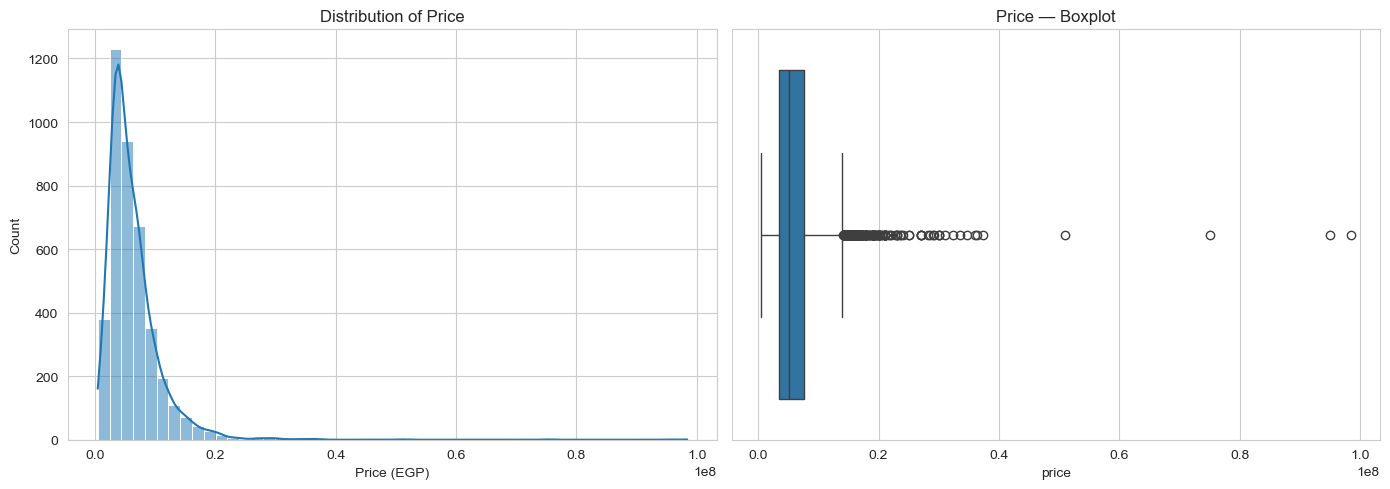

count    4.072000e+03
mean     6.256714e+06
std      4.687280e+06
min      5.000000e+05
25%      3.500000e+06
50%      5.151000e+06
75%      7.700000e+06
max      9.838000e+07
Name: price, dtype: float64


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price (EGP)')

sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('Price — Boxplot')
plt.tight_layout()
plt.show()

print(df['price'].describe())


### 4.2 Numeric feature relationships

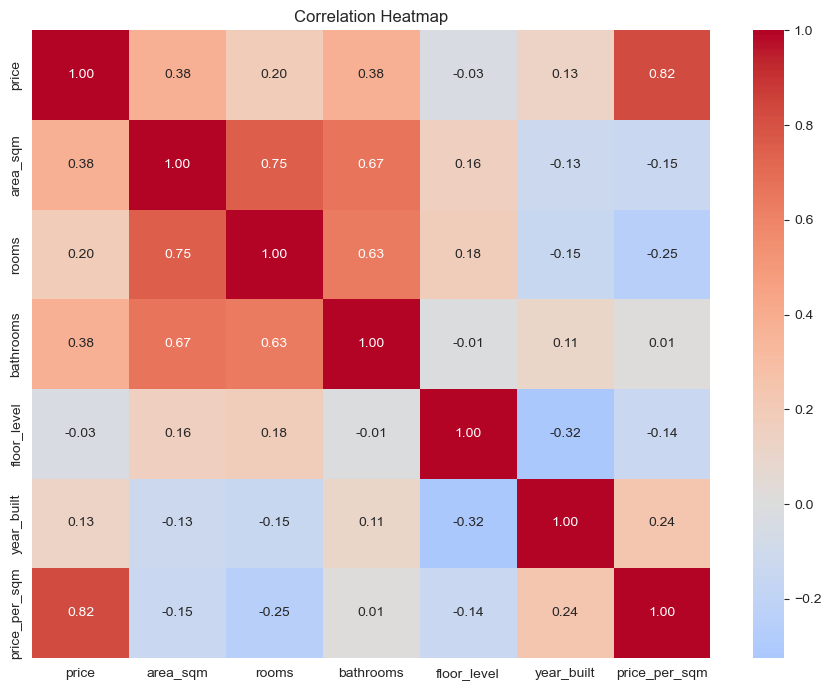

In [12]:

num_cols = ['price', 'area_sqm', 'rooms', 'bathrooms', 'floor_level', 'year_built', 'price_per_sqm']

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


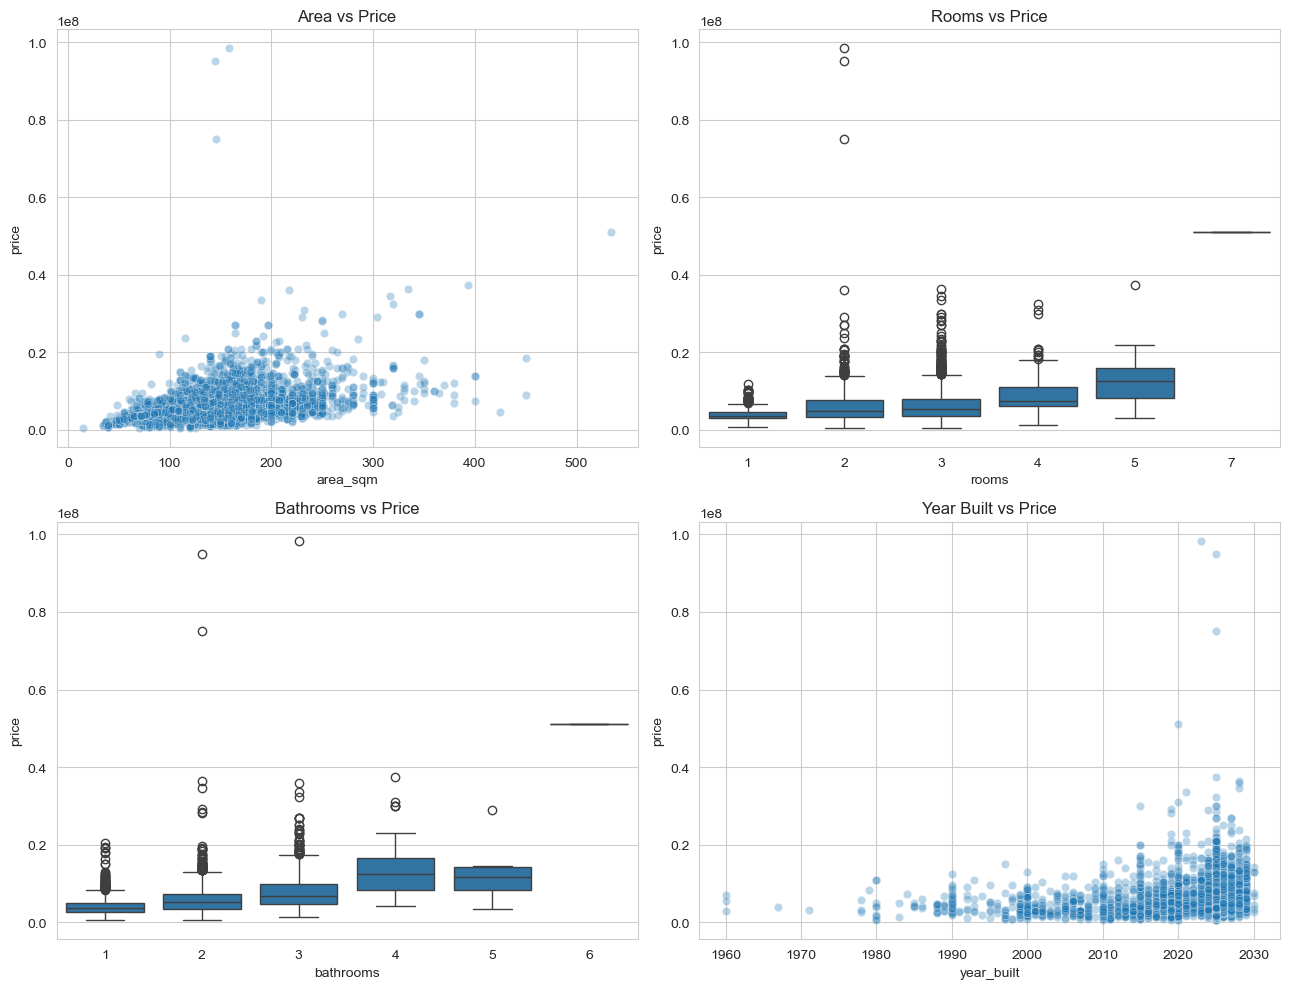

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(data=df, x='area_sqm', y='price', alpha=0.3, ax=axes[0,0])
axes[0,0].set_title('Area vs Price')

sns.boxplot(data=df, x='rooms', y='price', ax=axes[0,1])
axes[0,1].set_title('Rooms vs Price')

sns.boxplot(data=df, x='bathrooms', y='price', ax=axes[1,0])
axes[1,0].set_title('Bathrooms vs Price')

sns.scatterplot(data=df, x='year_built', y='price', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Year Built vs Price')

plt.tight_layout()
plt.show()


### 4.3 Categorical features vs price

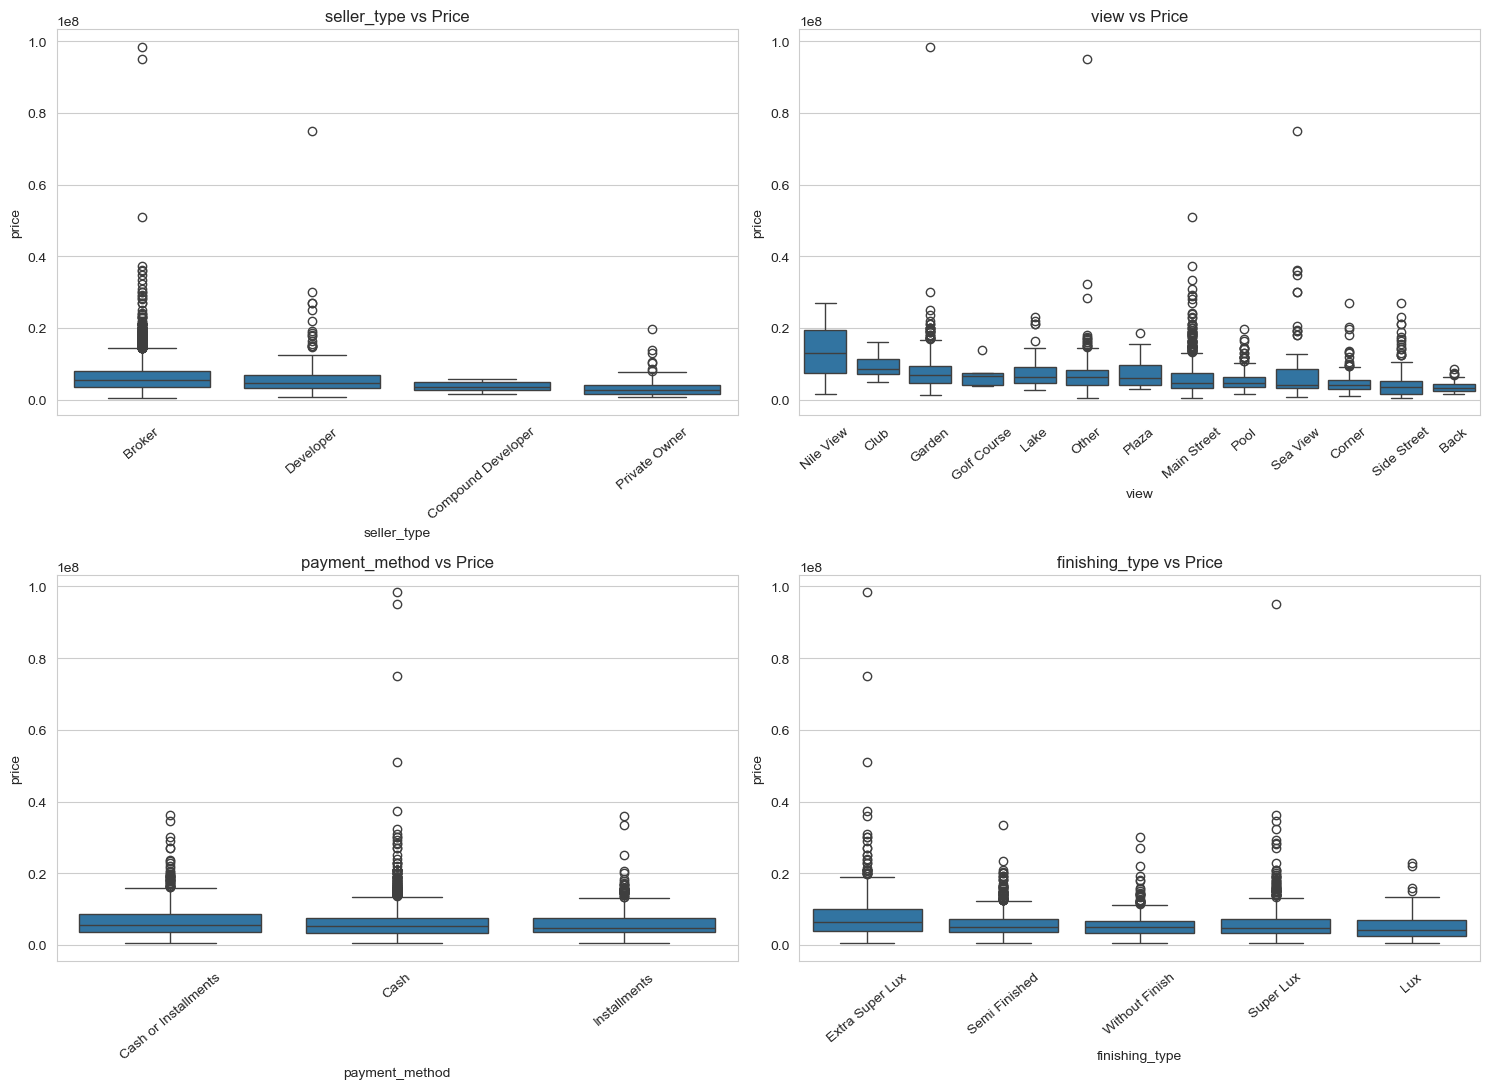

In [14]:

cat_cols = ['seller_type', 'view', 'payment_method', 'finishing_type']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price', order=order, ax=ax)
    ax.set_title(f'{col} vs Price')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


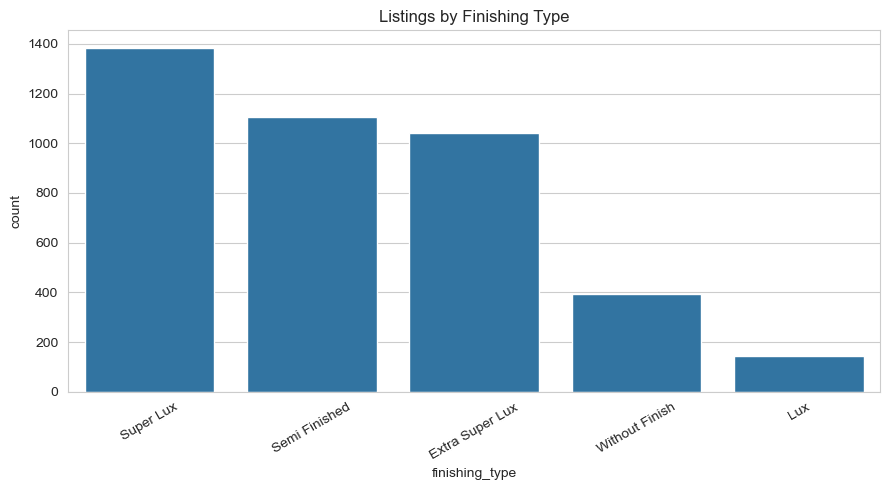

In [15]:

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='finishing_type',
              order=df['finishing_type'].value_counts().index)
plt.title('Listings by Finishing Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**EDA takeaways**
- `area_sqm` has the strongest linear relationship with `price` (as expected).
- Price rises with `rooms` and `bathrooms`, but with diminishing/noisier returns past 4.
- `finishing_type` and `view` create clear separation in price — `Extra Super Lux` /
  premium views command a real premium.
- Newer `year_built` (a lot of off-plan / under-construction stock, hence years up to
  2030) trends toward higher prices.


## 5. Feature Engineering

- `price_per_sqm` is dropped from the model features — it's algebraically derived
  from `price / area_sqm`, so including it would leak the target.
- Categorical columns are one-hot encoded.
- Numeric columns are scaled with `MinMaxScaler` (fit on train only, to avoid leakage).
- Split: 80% train / 20% test.


In [16]:

target = 'price'
drop_cols = ['price', 'price_per_sqm']

X = df.drop(columns=drop_cols)
y = df[target]

numeric_features = ['area_sqm', 'rooms', 'bathrooms', 'floor_level', 'year_built']
categorical_features = ['seller_type', 'view', 'payment_method', 'finishing_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (3257, 9)  Test shape: (815, 9)


In [17]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features)
    ]
)

# fit on train, transform both (avoids leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_proc  = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

print('Processed feature matrix shape:', X_train_proc.shape)
X_train_proc.head()


Processed feature matrix shape: (3257, 26)


,area_sqm,rooms,bathrooms,floor_level,year_built,seller_type_Compound Developer,seller_type_Developer,seller_type_Private Owner,view_Club,view_Corner,view_Garden,view_Golf Course,view_Lake,view_Main Street,view_Nile View,view_Other,view_Plaza,view_Pool,view_Sea View,view_Side Street,payment_method_Cash or Installments,payment_method_Installments,finishing_type_Lux,finishing_type_Semi Finished,finishing_type_Super Lux,finishing_type_Without Finish
2973,0.294798,0.333333,0.4,0.111111,0.971429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
88,0.150289,0.000000,0.0,0.000000,0.942857,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3747,0.317919,0.333333,0.4,0.111111,0.928571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1732,0.211946,0.166667,0.0,0.055556,0.614286,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4015,0.394990,0.333333,0.2,0.611111,0.428571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. Baseline Models

Same loop structure as your template (fit → predict → metrics → plots →
store results in a dict), adapted to regression:
- **Metrics:** MAE, RMSE, R², MAPE (train & test, to check over/under-fitting)
- **Plots per model:** Predicted vs Actual scatter, Residuals plot


In [18]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
}


  0%|                                                                                           | 0/14 [00:00<?, ?it/s]


Linear Regression
Train -> MAE: 2,301,706 | RMSE: 4,041,785 | R2: 0.309 | MAPE: 0.468
Test  -> MAE: 2,214,387 | RMSE: 3,117,632 | R2: 0.361 | MAPE: 0.439


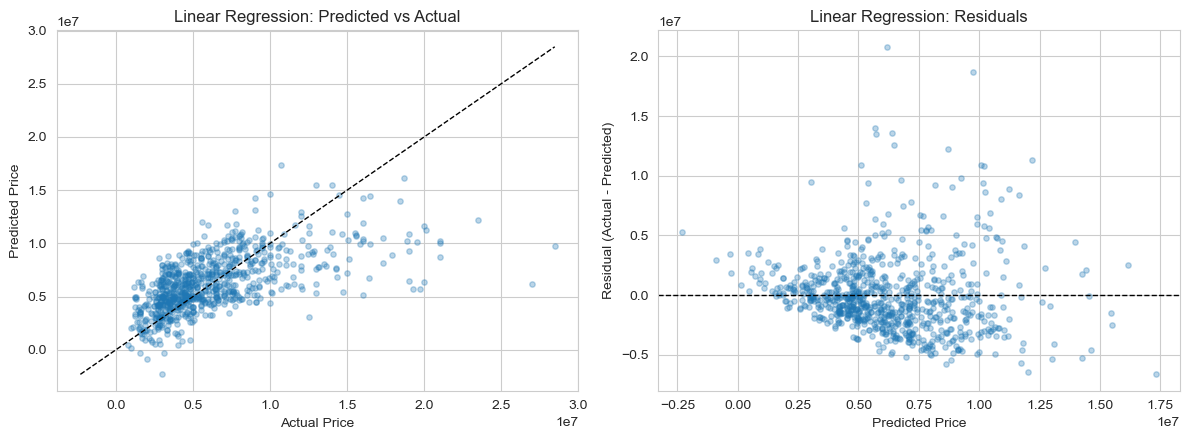

  7%|█████▉                                                                             | 1/14 [00:00<00:07,  1.85it/s]


Ridge
Train -> MAE: 2,297,922 | RMSE: 4,043,264 | R2: 0.309 | MAPE: 0.468
Test  -> MAE: 2,213,434 | RMSE: 3,118,685 | R2: 0.361 | MAPE: 0.440


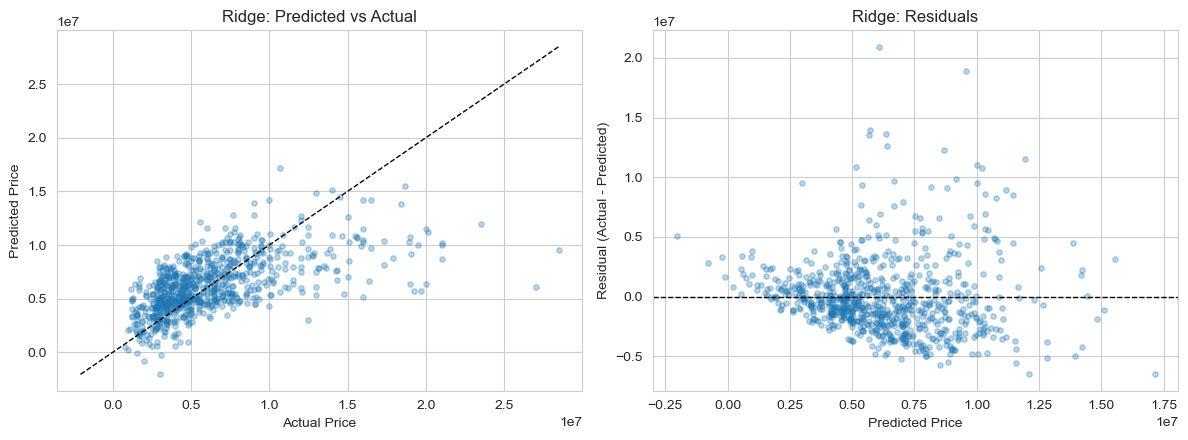

 14%|███████████▊                                                                       | 2/14 [00:01<00:06,  1.78it/s]


Lasso
Train -> MAE: 2,301,703 | RMSE: 4,041,785 | R2: 0.309 | MAPE: 0.468
Test  -> MAE: 2,214,387 | RMSE: 3,117,632 | R2: 0.361 | MAPE: 0.439


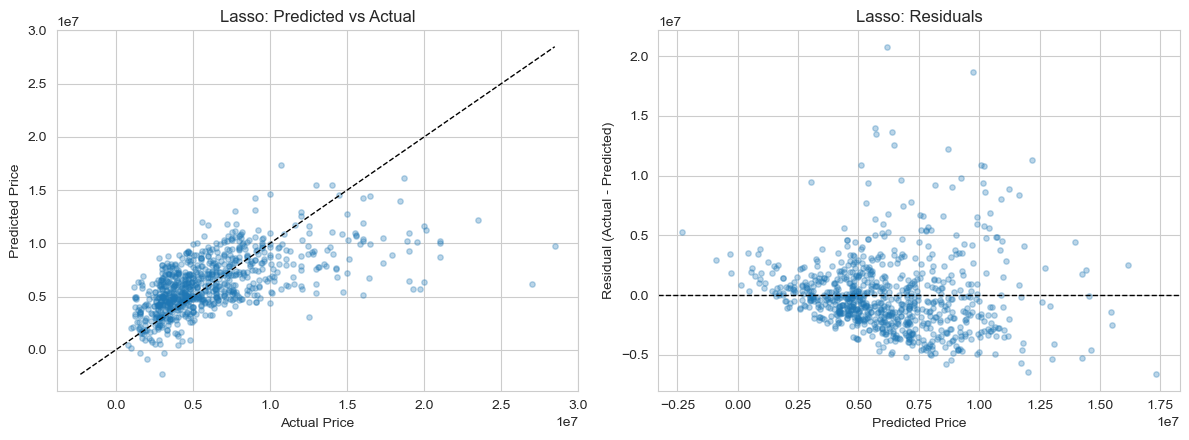

 21%|█████████████████▊                                                                 | 3/14 [00:01<00:05,  1.85it/s]


KNN
Train -> MAE: 1,762,747 | RMSE: 3,432,675 | R2: 0.502 | MAPE: 0.331
Test  -> MAE: 2,092,444 | RMSE: 3,340,129 | R2: 0.267 | MAPE: 0.377


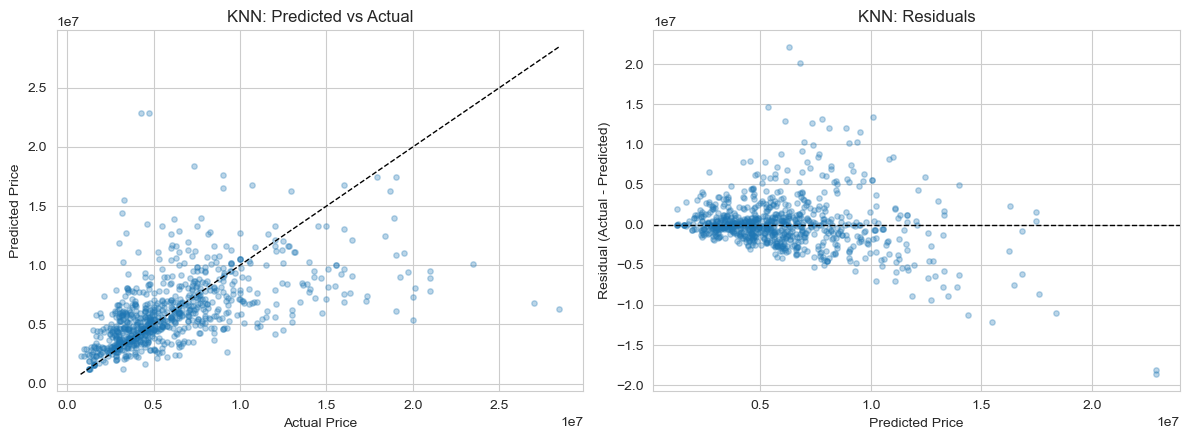

 29%|███████████████████████▋                                                           | 4/14 [00:04<00:15,  1.57s/it]


SVR
Train -> MAE: 2,894,275 | RMSE: 4,982,299 | R2: -0.050 | MAPE: 0.580
Test  -> MAE: 2,729,872 | RMSE: 4,015,281 | R2: -0.059 | MAPE: 0.527


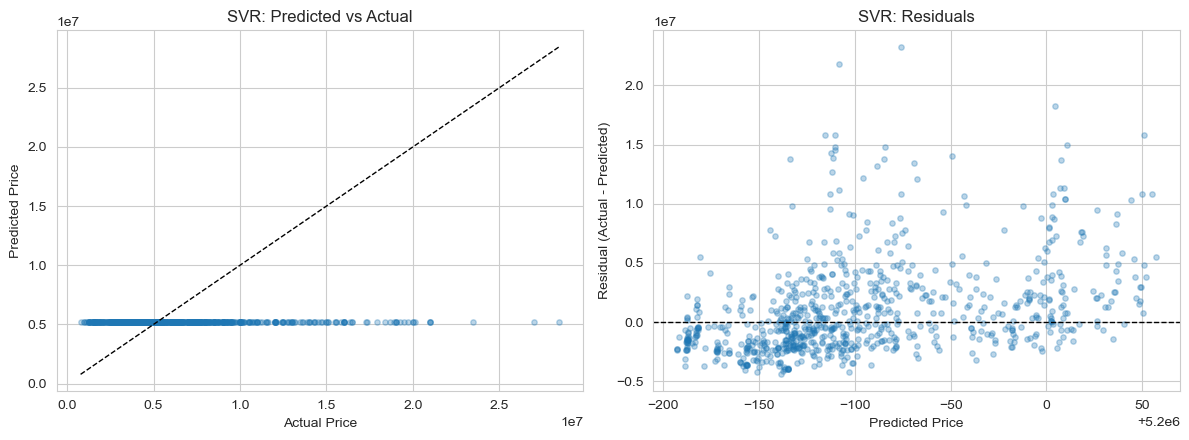

 36%|█████████████████████████████▋                                                     | 5/14 [00:08<00:22,  2.46s/it]


Decision Tree
Train -> MAE: 52,909 | RMSE: 313,669 | R2: 0.996 | MAPE: 0.010
Test  -> MAE: 2,493,340 | RMSE: 5,290,186 | R2: -0.839 | MAPE: 0.447


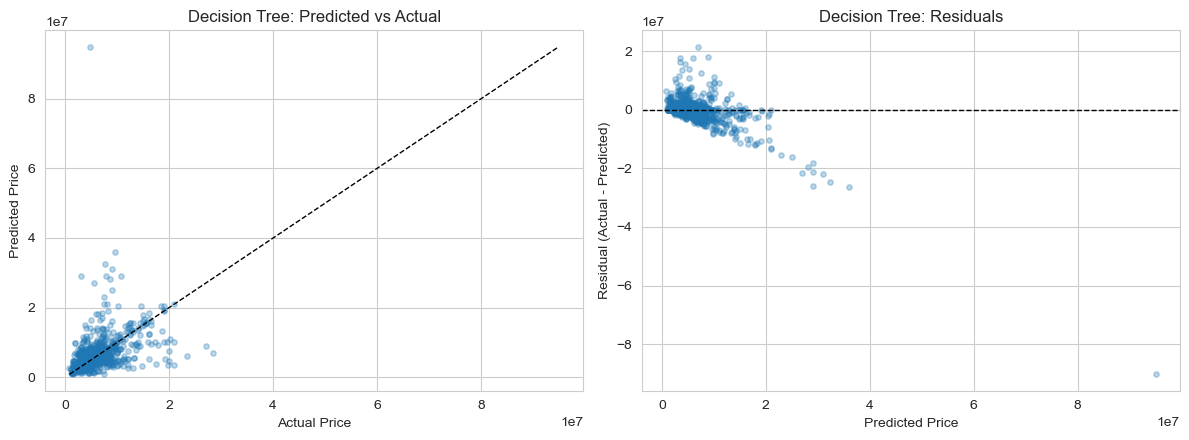

 43%|███████████████████████████████████▌                                               | 6/14 [00:09<00:14,  1.77s/it]


Random Forest
Train -> MAE: 735,248 | RMSE: 1,483,973 | R2: 0.907 | MAPE: 0.134
Test  -> MAE: 1,902,295 | RMSE: 3,544,671 | R2: 0.175 | MAPE: 0.341


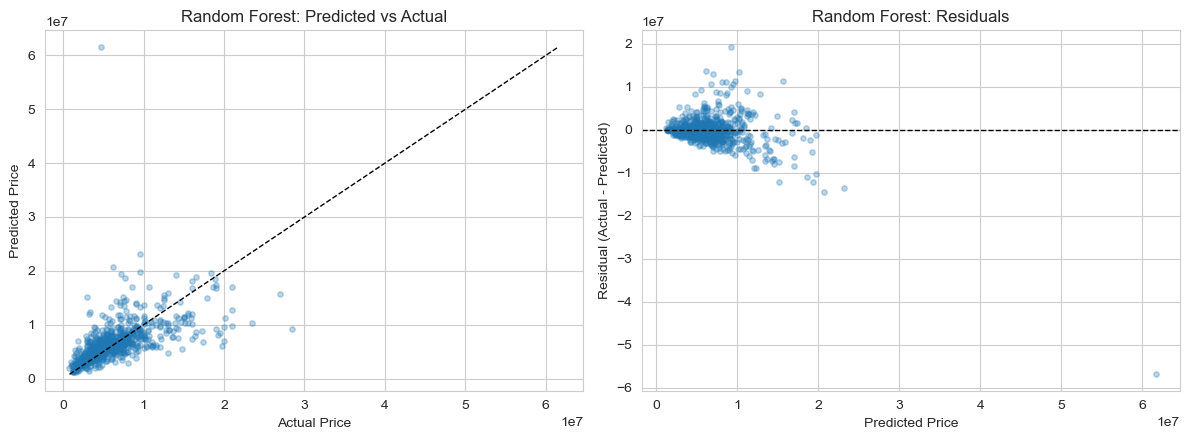

 50%|█████████████████████████████████████████▌                                         | 7/14 [00:10<00:10,  1.51s/it]


Extra Trees
Train -> MAE: 52,952 | RMSE: 313,671 | R2: 0.996 | MAPE: 0.010
Test  -> MAE: 1,977,487 | RMSE: 4,487,744 | R2: -0.323 | MAPE: 0.348


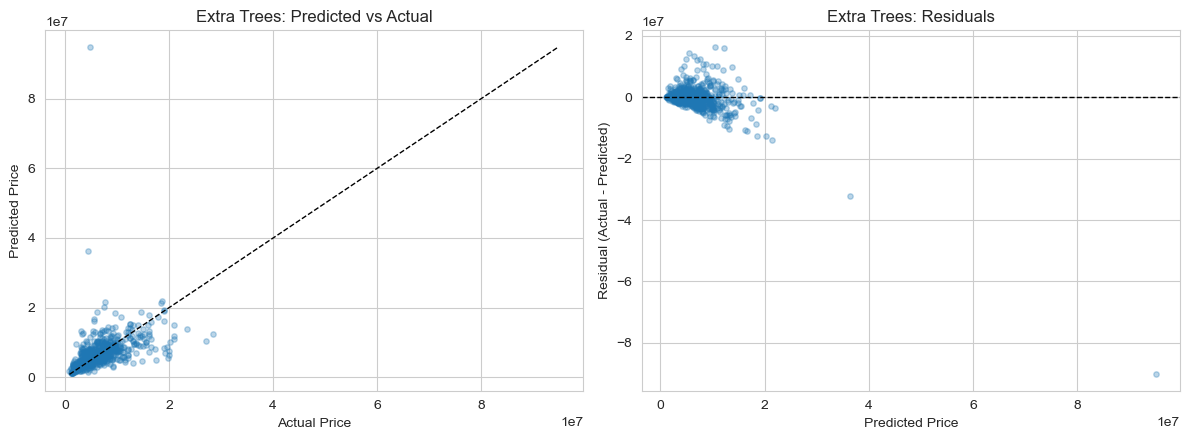

 57%|███████████████████████████████████████████████▍                                   | 8/14 [00:11<00:07,  1.31s/it]


AdaBoost
Train -> MAE: 2,950,010 | RMSE: 3,911,282 | R2: 0.353 | MAPE: 0.734
Test  -> MAE: 3,089,568 | RMSE: 4,754,643 | R2: -0.485 | MAPE: 0.732


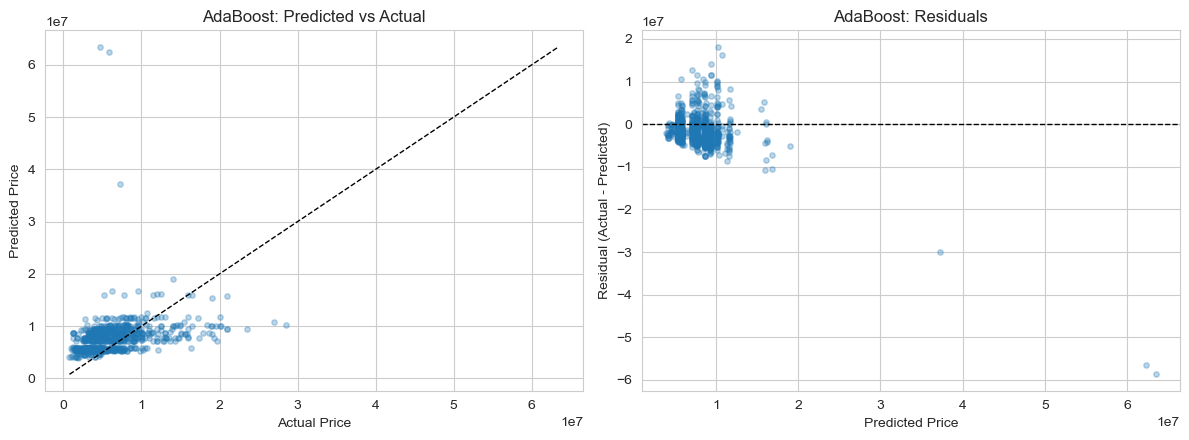

 64%|█████████████████████████████████████████████████████▎                             | 9/14 [00:11<00:05,  1.14s/it]


Gradient Boosting
Train -> MAE: 1,932,519 | RMSE: 3,494,894 | R2: 0.484 | MAPE: 0.378
Test  -> MAE: 1,975,908 | RMSE: 2,892,827 | R2: 0.450 | MAPE: 0.376


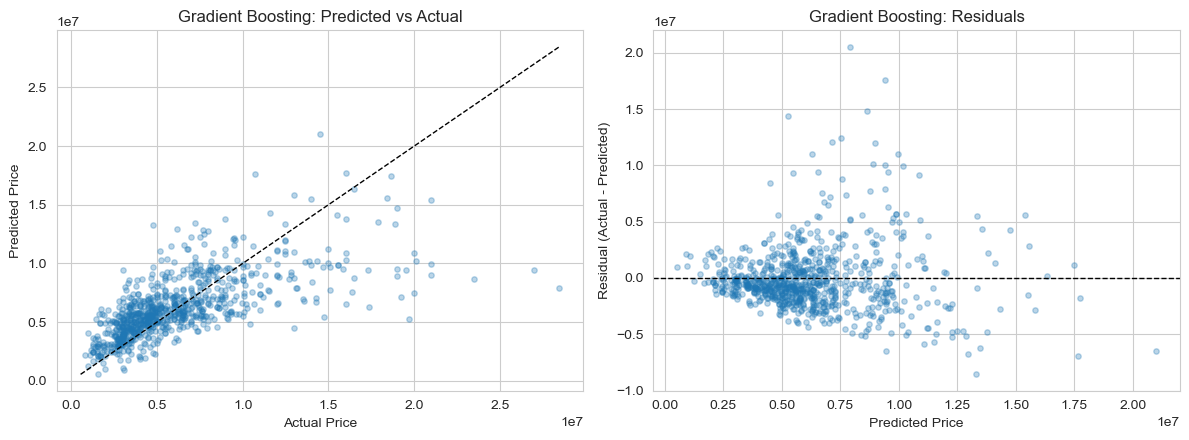

 71%|██████████████████████████████████████████████████████████▌                       | 10/14 [00:13<00:04,  1.16s/it]


HistGradientBoosting
Train -> MAE: 1,553,059 | RMSE: 2,882,138 | R2: 0.649 | MAPE: 0.290
Test  -> MAE: 1,849,382 | RMSE: 2,920,781 | R2: 0.440 | MAPE: 0.333


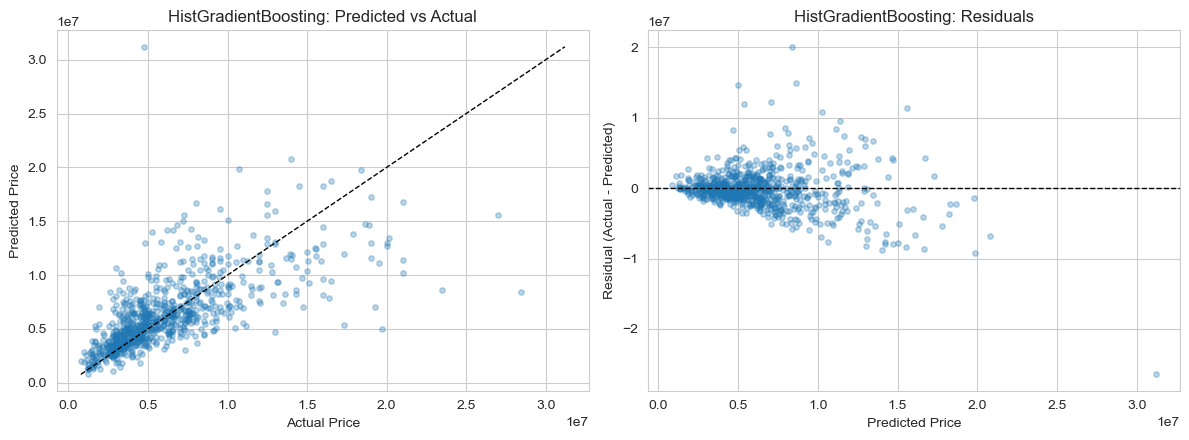

 79%|████████████████████████████████████████████████████████████████▍                 | 11/14 [00:14<00:03,  1.22s/it]


XGBoost
Train -> MAE: 964,603 | RMSE: 1,535,220 | R2: 0.900 | MAPE: 0.189
Test  -> MAE: 1,965,452 | RMSE: 3,813,799 | R2: 0.044 | MAPE: 0.353


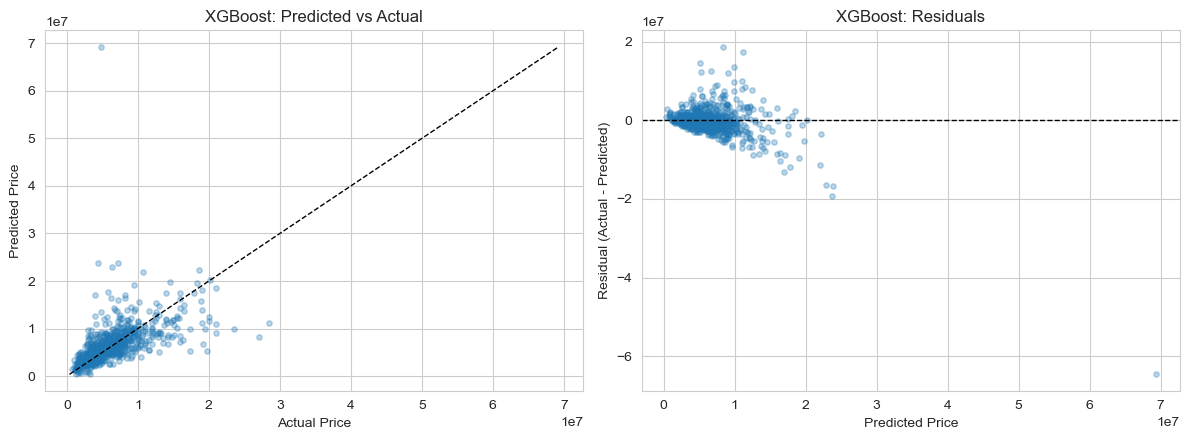

 86%|██████████████████████████████████████████████████████████████████████▎           | 12/14 [00:15<00:02,  1.14s/it]


CatBoost
Train -> MAE: 1,432,105 | RMSE: 2,342,923 | R2: 0.768 | MAPE: 0.277
Test  -> MAE: 1,949,124 | RMSE: 3,350,674 | R2: 0.262 | MAPE: 0.356


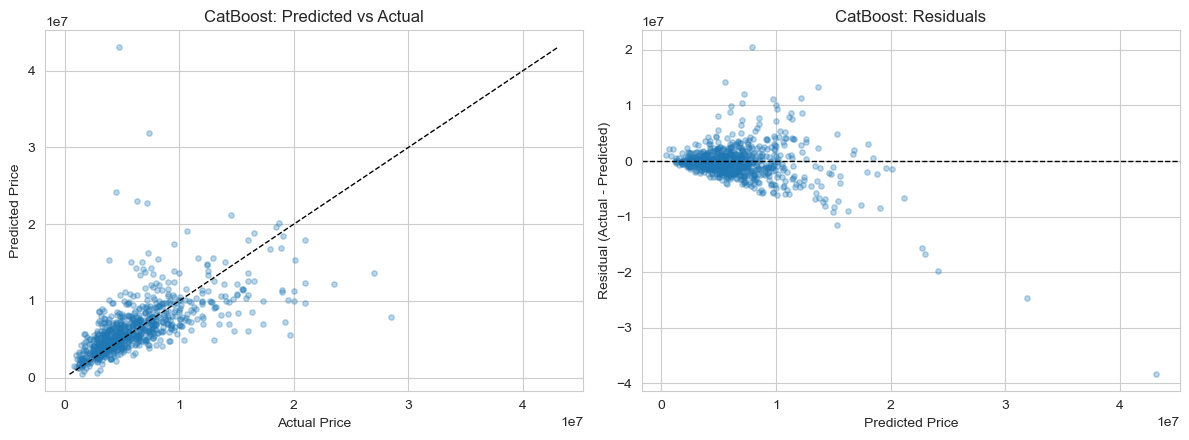

 93%|████████████████████████████████████████████████████████████████████████████▏     | 13/14 [00:18<00:01,  1.74s/it]


LightGBM
Train -> MAE: 1,538,438 | RMSE: 2,837,334 | R2: 0.660 | MAPE: 0.288
Test  -> MAE: 1,857,038 | RMSE: 2,951,473 | R2: 0.428 | MAPE: 0.335


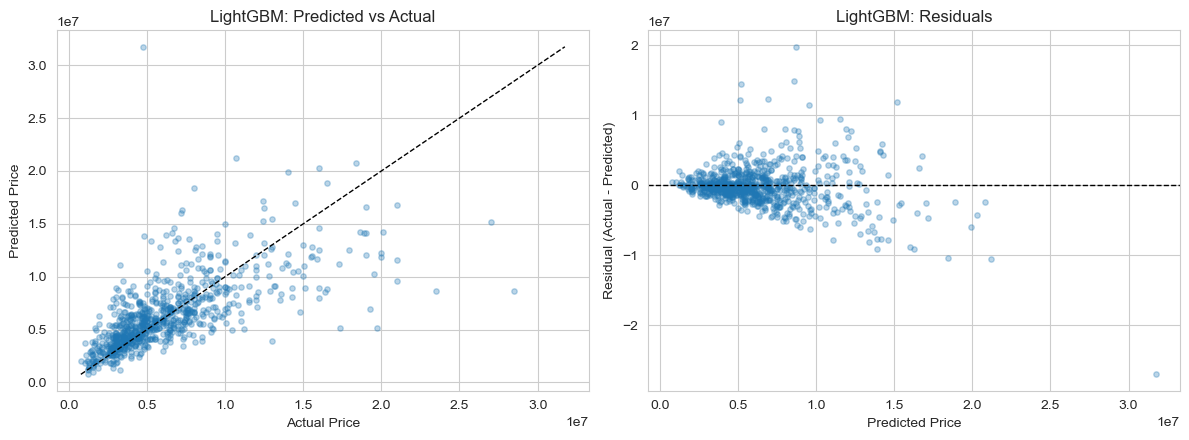

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:19<00:00,  1.37s/it]


100%|██████████| 14/14 [00:09<00:00,  1.51it/s]

In [19]:

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

results = {}

for name, model in tqdm(models.items()):
    model.fit(X_train_proc, y_train)

    train_pred = model.predict(X_train_proc)
    test_pred  = model.predict(X_test_proc)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics  = regression_metrics(y_test, test_pred)

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Train -> MAE: {train_metrics['MAE']:,.0f} | RMSE: {train_metrics['RMSE']:,.0f} | "
          f"R2: {train_metrics['R2']:.3f} | MAPE: {train_metrics['MAPE']:.3f}")
    print(f"Test  -> MAE: {test_metrics['MAE']:,.0f} | RMSE: {test_metrics['RMSE']:,.0f} | "
          f"R2: {test_metrics['R2']:.3f} | MAPE: {test_metrics['MAPE']:.3f}")

    # Predicted vs Actual + Residuals
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].scatter(y_test, test_pred, alpha=0.3, s=15)
    lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
    axes[0].plot(lims, lims, 'k--', linewidth=1)
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')
    axes[0].set_title(f'{name}: Predicted vs Actual')

    residuals = y_test - test_pred
    axes[1].scatter(test_pred, residuals, alpha=0.3, s=15)
    axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Predicted Price')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title(f'{name}: Residuals')

    plt.tight_layout()
    plt.show()

    results[name] = {
        "Train MAE": train_metrics["MAE"], "Test MAE": test_metrics["MAE"],
        "Train RMSE": train_metrics["RMSE"], "Test RMSE": test_metrics["RMSE"],
        "Train R2": train_metrics["R2"], "Test R2": test_metrics["R2"],
        "Train MAPE": train_metrics["MAPE"], "Test MAPE": test_metrics["MAPE"],
    }


### 6.1 Model comparison

In [20]:

results_df = pd.DataFrame(results).T.sort_values('Test R2', ascending=False)
results_df.style.background_gradient(subset=['Test R2'], cmap='Greens')\
                 .background_gradient(subset=['Test RMSE'], cmap='Reds_r')


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train MAPE,Test MAPE
Gradient Boosting,1932519.344504,1975907.775898,3494893.541380,2892827.056736,0.483521,0.450213,0.377732,0.376454
HistGradientBoosting,1553059.456991,1849381.833528,2882138.272671,2920780.924581,0.648751,0.439537,0.289621,0.332650
LightGBM,1538437.721650,1857038.195818,2837334.282407,2951472.781671,0.659587,0.427696,0.287644,0.335047
Lasso,2301702.994686,2214386.567158,4041785.292776,3117632.261387,0.309233,0.361444,0.468434,0.438572
Linear Regression,2301706.051232,2214386.523008,4041785.291397,3117632.334154,0.309233,0.361444,0.468435,0.438571
Ridge,2297922.315032,2213434.402433,4043264.090260,3118685.284347,0.308728,0.361013,0.468235,0.439988
KNN,1762746.996254,2092444.033374,3432674.984154,3340129.247450,0.501746,0.267048,0.330625,0.376825
CatBoost,1432105.215802,1949124.269735,2342923.220201,3350674.407912,0.767886,0.262412,0.276750,0.355935
Random Forest,735248.222126,1902294.959042,1483972.747314,3544671.277963,0.906881,0.174530,0.134422,0.340907
XGBoost,964603.107888,1965452.282094,1535220.147478,3813798.903786,0.900339,0.044425,0.189084,0.352623


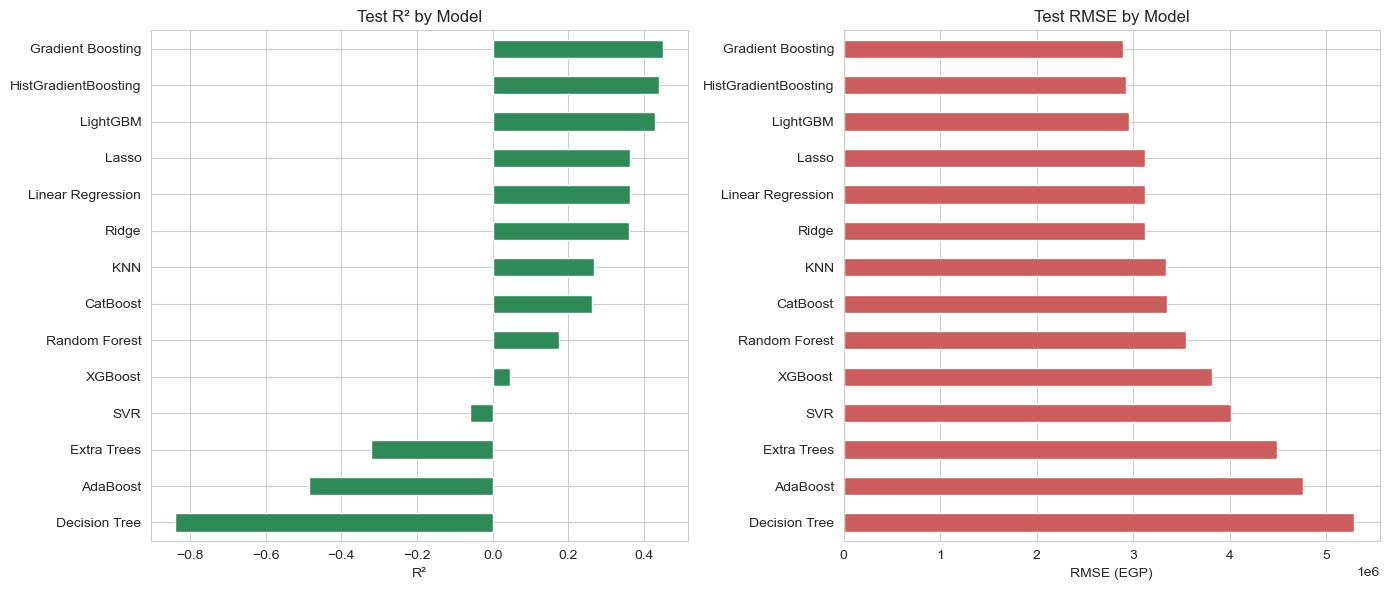

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_df['Test R2'].sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Test R² by Model')
axes[0].set_xlabel('R²')

results_df['Test RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Test RMSE by Model')
axes[1].set_xlabel('RMSE (EGP)')

plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning (GridSearchCV)

We tune the top 3 performing models from the baseline comparison above with
5-fold cross-validated grid search, optimizing for R².


In [22]:

top_3 = results_df.head(3).index.tolist()
print('Tuning:', top_3)


Tuning: ['Gradient Boosting', 'HistGradientBoosting', 'LightGBM']


In [23]:

param_grids = {
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    },
    "Extra Trees": {
        "n_estimators": [200, 400],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
    },
    "HistGradientBoosting": {
        "max_iter": [150, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [None, 10],
    },
    "XGBoost": {
        "n_estimators": [200, 400],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5, 7],
    },
    "LightGBM": {
        "n_estimators": [200, 400],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 63],
    },
    "CatBoost": {
        "iterations": [300, 600],
        "learning_rate": [0.05, 0.1],
        "depth": [4, 6],
    },
    "Decision Tree": {
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
    },
    "Ridge": {"alpha": [0.1, 1.0, 10.0, 50.0]},
    "Lasso": {"alpha": [0.1, 1.0, 10.0, 50.0]},
    "SVR": {"C": [1, 10, 50], "kernel": ["rbf", "linear"]},
    "Linear Regression": {},
    "AdaBoost": {"n_estimators": [50, 100, 200], "learning_rate": [0.05, 0.1, 1.0]},
}


In [24]:

tuned_results = {}
best_estimators = {}

for name in tqdm(top_3):
    grid = param_grids.get(name, {})
    if not grid:
        # nothing to tune (e.g. plain Linear Regression) -> just refit as baseline
        best_estimators[name] = models[name]
        tuned_results[name] = results[name]
        print(f"{name}: no hyperparameters to tune, keeping baseline fit.")
        continue

    search = GridSearchCV(
        estimator=models[name],
        param_grid=grid,
        scoring='r2',
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train_proc, y_train)

    best_model = search.best_estimator_
    best_estimators[name] = best_model

    train_pred = best_model.predict(X_train_proc)
    test_pred  = best_model.predict(X_test_proc)
    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics  = regression_metrics(y_test, test_pred)

    print(f"\n{name}")
    print("Best params:", search.best_params_)
    print(f"Best CV R2: {search.best_score_:.4f}")
    print(f"Test -> MAE: {test_metrics['MAE']:,.0f} | RMSE: {test_metrics['RMSE']:,.0f} | "
          f"R2: {test_metrics['R2']:.3f} | MAPE: {test_metrics['MAPE']:.3f}")

    tuned_results[name] = {
        "Train MAE": train_metrics["MAE"], "Test MAE": test_metrics["MAE"],
        "Train RMSE": train_metrics["RMSE"], "Test RMSE": test_metrics["RMSE"],
        "Train R2": train_metrics["R2"], "Test R2": test_metrics["R2"],
        "Train MAPE": train_metrics["MAPE"], "Test MAPE": test_metrics["MAPE"],
        "Best Params": search.best_params_,
    }


 33%|████████████████████████████                                                        | 1/3 [00:14<00:29, 14.64s/it]


Gradient Boosting
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV R2: 0.3851
Test -> MAE: 1,932,858 | RMSE: 2,842,102 | R2: 0.469 | MAPE: 0.363


 67%|████████████████████████████████████████████████████████                            | 2/3 [00:20<00:09,  9.51s/it]


HistGradientBoosting
Best params: {'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 150}
Best CV R2: 0.3864
Test -> MAE: 1,818,455 | RMSE: 2,873,214 | R2: 0.458 | MAPE: 0.330


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:34<00:00, 11.53s/it]


LightGBM
Best params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
Best CV R2: 0.3795
Test -> MAE: 1,839,510 | RMSE: 2,944,637 | R2: 0.430 | MAPE: 0.333



LightGBM
Best params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
Best CV R2: 0.3795
Test -> MAE: 1,839,510 | RMSE: 2,944,637 | R2: 0.430 | MAPE: 0.333


In [25]:

tuned_df = pd.DataFrame(tuned_results).T
tuned_df[['Train MAE','Test MAE','Train RMSE','Test RMSE','Train R2','Test R2','Train MAPE','Test MAPE']] \
    .sort_values('Test R2', ascending=False) \
    .style.background_gradient(subset=['Test R2'], cmap='Greens')


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train MAPE,Test MAPE
Gradient Boosting,1853919.181482,1932858.406231,3389665.694461,2842102.477264,0.514154,0.469325,0.359352,0.362956
HistGradientBoosting,1631717.531391,1818454.778306,3044081.828904,2873213.685908,0.608170,0.457643,0.304652,0.329822
LightGBM,1535704.541879,1839510.302077,2836932.005871,2944637.022307,0.659684,0.430344,0.287050,0.333220


## 8. Final Model & Feature Importance

In [26]:

best_name = tuned_df['Test R2'].astype(float).idxmax()
best_model = best_estimators[best_name]
print(f"Best model overall: {best_name}")
print(tuned_df.loc[best_name])


Best model overall: Gradient Boosting
Train MAE                                         1853919.181482
Test MAE                                          1932858.406231
Train RMSE                                        3389665.694461
Test RMSE                                         2842102.477264
Train R2                                                0.514154
Test R2                                                 0.469325
Train MAPE                                              0.359352
Test MAPE                                               0.362956
Best Params    {'learning_rate': 0.05, 'max_depth': 3, 'n_est...
Name: Gradient Boosting, dtype: object


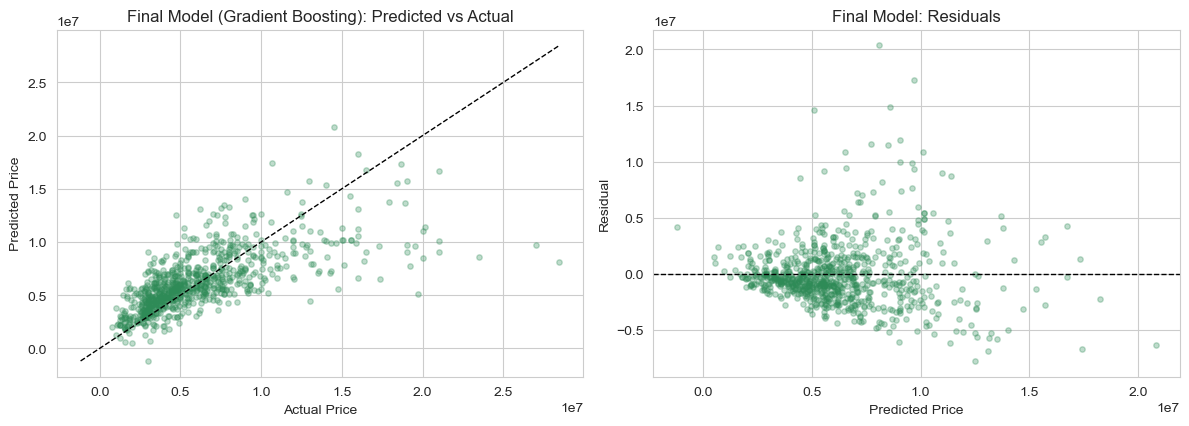

In [27]:

final_pred = best_model.predict(X_test_proc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, final_pred, alpha=0.3, s=15, color='seagreen')
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Final Model ({best_name}): Predicted vs Actual')

residuals = y_test - final_pred
axes[1].scatter(final_pred, residuals, alpha=0.3, s=15, color='seagreen')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Final Model: Residuals')

plt.tight_layout()
plt.show()


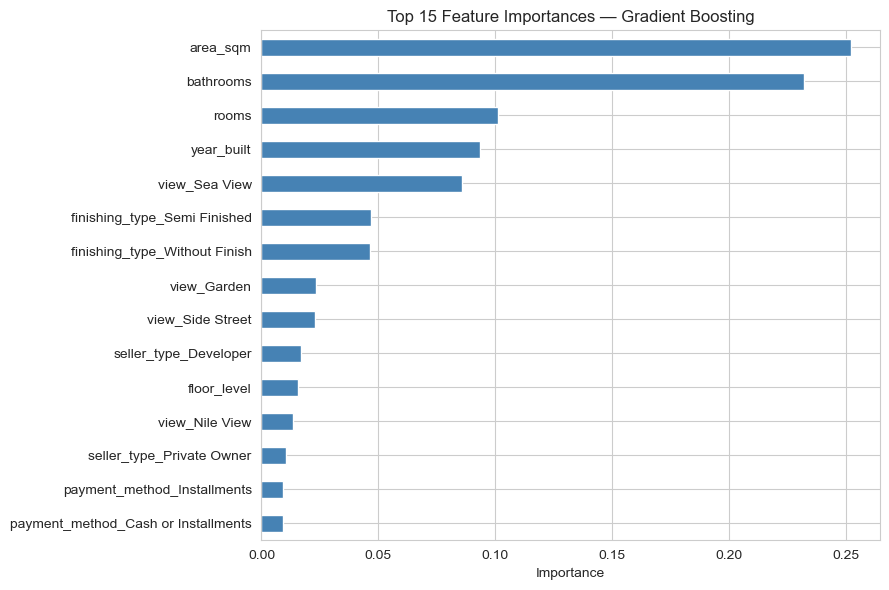

In [28]:

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    importances.sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_ (e.g. linear/kernel model).")


## 9. Conclusion

- After cleaning (unit parsing, fixing the swapped-column corruption, removing
  unrealistic outliers, and dropping duplicates), the dataset went from 5,578 raw
  rows to a clean modeling set.
- `area_sqm`, `finishing_type`, and `view` are the strongest price drivers.
- Tree-ensemble models (Random Forest / Gradient Boosting family) outperform linear
  and distance-based models on this data, as expected for a mix of numeric and
  categorical features with non-linear interactions.
- `price_per_sqm` was intentionally excluded from modeling features since it's
  derived directly from the target (`price / area_sqm`) and would otherwise leak
  the answer.

**Possible next steps:** engineer a `building_age` feature, try target
log-transformation (`price` is right-skewed) to stabilize variance, or collect
location/neighborhood data — a major real-world price driver that isn't present
in this dataset.
